            Broadcasting  Transplant_Rows  Transplant_NotRows  Parachute  \
Date                                                                       
1992-04-01         82.72             1.78               13.71        0.0   
1992-09-01         31.67             2.10               65.69        0.0   
1993-04-01         83.47             3.08               12.71        0.0   
1993-09-01         78.99             3.34               16.72        0.0   
1994-04-01         85.88             1.36               12.65        0.0   

            Machine  Other(sowing)  
Date                                
1992-04-01      0.0           1.80  
1992-09-01      0.0           0.54  
1993-04-01      0.0           0.74  
1993-09-01      0.0           0.96  
1994-04-01      0.0           0.11  
<class 'pandas.DataFrame'>
DatetimeIndex: 67 entries, 1992-04-01 to 2025-04-01
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  

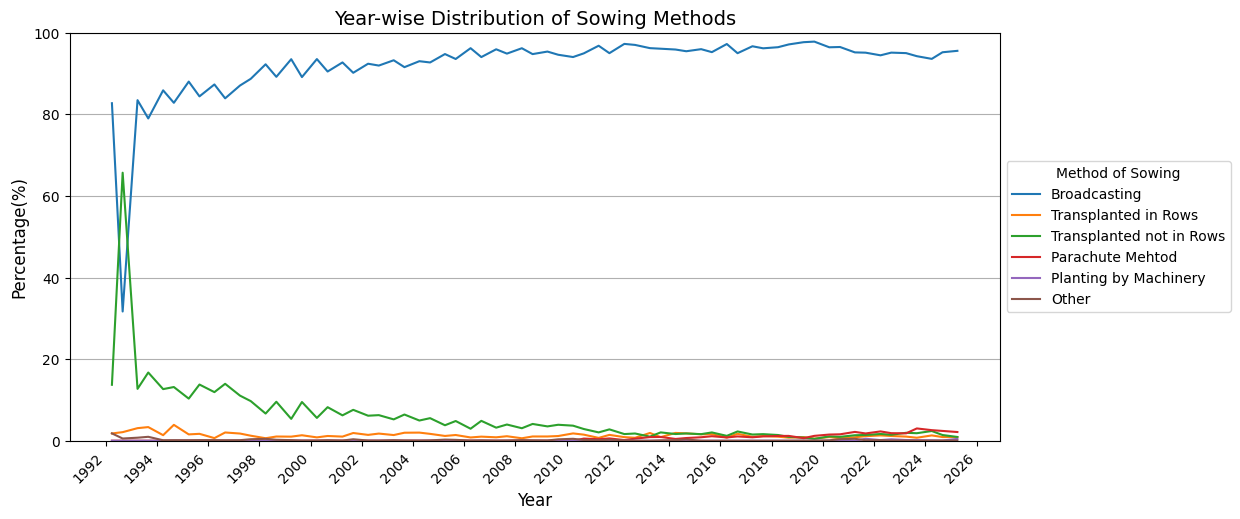

In [1]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error

mpl.rcParams['figure.figsize'] = (10, 8)
mpl.rcParams['axes.grid'] = False

# =========================================================
# LOAD DATA
# =========================================================
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:, :]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df[['Date', 'Broadcasting', 'Transplant_Rows',
         'Transplant_NotRows', 'Parachute', 'Machine', 'Other(sowing)']]
df.set_index('Date', inplace=True)

print(df.head())
print(df.info())

# =========================================================
# PLOT ORIGINAL DATA
# =========================================================

ax = df[['Broadcasting',
       'Transplant_Rows', 'Transplant_NotRows', 'Parachute', 'Machine',
       'Other(sowing)']].plot(figsize=(12,6))

ax.xaxis.set_major_locator(mdates.YearLocator(2))       # tick every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year
ax.set_ylim(0,100)
plt.xticks(rotation=45)
plt.title("Year-wise Distribution of Sowing Methods", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage(%)", fontsize=12)
plt.legend(["Broadcasting","Transplanted in Rows","Transplanted not in Rows", "Parachute Mehtod", "Planting by Machinery", "Other"], title= "Method of Sowing",loc="center left",
           bbox_to_anchor=(1, 0.5))
plt.grid(axis='y')
plt.show()

In [2]:

# =========================================================
# ADF TEST FUNCTION
# =========================================================
def adf_check(series):
    result = adfuller(series.dropna())
    return result[0], result[1]

# =========================================================
# CHECK ORIGINAL STATIONARITY
# =========================================================
print("\nADF TEST RESULTS (ORIGINAL SERIES)")
diff_count = {}

for column in df.columns:
    adf_stat, p_value = adf_check(df[column])
    print(f"\n{column}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")

    d = 0
    temp_series = df[column].copy()
    while adf_check(temp_series)[1] > 0.05:
        temp_series = temp_series.diff().dropna()
        d += 1
        if d == 3:
            break

    diff_count[column] = d
    print(f"  Differencing Needed : {d}")

# =========================================================
# USE SAME DIFFERENCING ORDER
# =========================================================
max_diff = max(diff_count.values())
print(f"\nMaximum Differencing Order : {max_diff}")



ADF TEST RESULTS (ORIGINAL SERIES)

Broadcasting
  ADF Statistic : -2.0091
  p-value       : 0.2826
  Differencing Needed : 1

Transplant_Rows
  ADF Statistic : -4.0924
  p-value       : 0.0010
  Differencing Needed : 0

Transplant_NotRows
  ADF Statistic : -3.5351
  p-value       : 0.0071
  Differencing Needed : 0

Parachute
  ADF Statistic : 2.9740
  p-value       : 1.0000
  Differencing Needed : 1

Machine
  ADF Statistic : 2.5131
  p-value       : 0.9991
  Differencing Needed : 1

Other(sowing)
  ADF Statistic : -9.0252
  p-value       : 0.0000
  Differencing Needed : 0

Maximum Differencing Order : 1


In [3]:

# =========================================================
# DIFFERENCE ALL SERIES
# =========================================================
df_diff = df.copy()
for i in range(max_diff):
    df_diff = df_diff.diff()
df_diff = df_diff.dropna()

# =========================================================
# FINAL STATIONARITY CHECK
# =========================================================
print("\nFINAL STATIONARITY RESULTS")
for column in df_diff.columns:
    adf_stat, p_value = adf_check(df_diff[column])
    print(f"\n{column}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print("  Stationary" if p_value <= 0.05 else "  STILL NOT Stationary")


FINAL STATIONARITY RESULTS

Broadcasting
  ADF Statistic : -26.8474
  p-value       : 0.0000
  Stationary

Transplant_Rows
  ADF Statistic : -16.4657
  p-value       : 0.0000
  Stationary

Transplant_NotRows
  ADF Statistic : -26.4954
  p-value       : 0.0000
  Stationary

Parachute
  ADF Statistic : -3.4522
  p-value       : 0.0093
  Stationary

Machine
  ADF Statistic : -3.2361
  p-value       : 0.0180
  Stationary

Other(sowing)
  ADF Statistic : -9.2430
  p-value       : 0.0000
  Stationary


In [4]:

# =========================================================
# TRAIN TEST SPLIT (80 / 20)
# =========================================================
train_size = int(len(df_diff) * 0.8)
train = df_diff.iloc[:train_size]
test  = df_diff.iloc[train_size:]

print(f"\nTrain Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")


Train Shape : (52, 6)
Test Shape  : (14, 6)


In [5]:
# =========================================================
# ADD JITTER TO AVOID SINGULAR COVARIANCE MATRIX
# =========================================================
np.random.seed(42)
train_jittered = train + np.random.normal(0, 1e-6, train.shape)

# =========================================================
# SAFE LAG SELECTION
# =========================================================
n_obs        = len(train_jittered)
n_vars       = train_jittered.shape[1]
safe_maxlags = max(1, int((n_obs - 1) / (n_vars + 1)))
print(f"\nTrain observations    : {n_obs}")
print(f"Number of variables   : {n_vars}")
print(f"Safe max lags allowed : {safe_maxlags}")

selected_lag = 1
for try_lag in range(safe_maxlags, 0, -1):
    try:
        lag_result   = VAR(train_jittered).select_order(maxlags=try_lag)
        selected_lag = lag_result.selected_orders['aic']
        selected_lag = max(1, selected_lag)
        print(f"\nLag Order Selection:")
        print(lag_result.summary())
        print(f"Selected Lag (AIC) : {selected_lag}")
        break
    except Exception as e:
        print(f"  maxlags={try_lag} failed, trying lower...")
        continue


Train observations    : 52
Number of variables   : 6
Safe max lags allowed : 7
  maxlags=7 failed, trying lower...

Lag Order Selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -45.67     -45.43*   1.466e-20      -45.58
1      -46.34      -44.67   7.574e-21      -45.72
2      -46.04      -42.93   1.118e-20      -44.87
3      -46.65      -42.11   7.558e-21      -44.95
4      -47.17      -41.21   7.165e-21      -44.94
5      -47.96      -40.56   8.386e-21      -45.19
6     -50.99*      -42.16  2.842e-21*     -47.68*
-------------------------------------------------
Selected Lag (AIC) : 6


C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [6]:
# =========================================================
# FIT VAR MODEL
# =========================================================
var_model  = VAR(train_jittered)
var_result = var_model.fit(selected_lag)




C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [7]:

print("\nVAR MODEL SUMMARY")
print(var_result.summary())


VAR MODEL SUMMARY
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 03, Jun, 2026
Time:                     20:27:20
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -42.1622
Nobs:                     46.0000    HQIC:                  -47.6814
Log likelihood:           1003.08    FPE:                2.84190e-21
AIC:                     -50.9873    Det(Omega_mle):     8.23546e-23
--------------------------------------------------------------------
Results for equation Broadcasting
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                         0.258915         0.505420            0.512           0.608
L1.Broadcasting              23.746506        97.321888            0.244           0.807
L1

In [8]:
# =========================================================
# FORECASTING
# =========================================================
forecast_steps  = len(test)
lag_input       = train_jittered.values[-selected_lag:]

forecast_values = var_result.forecast(y=lag_input, steps=forecast_steps)
forecast_df     = pd.DataFrame(
    forecast_values,
    index=test.index,
    columns=test.columns
)

print("\nForecasted Differenced Values")
print(forecast_df.head())


Forecasted Differenced Values
            Broadcasting  Transplant_Rows  Transplant_NotRows  Parachute  \
Date                                                                       
2018-09-01      3.745049        -0.446602           -3.341289   0.267650   
2019-04-01     -3.725453        -0.021054            4.134663  -0.794979   
2019-09-01      4.476749         1.015966           -6.195162   0.581965   
2020-04-01     -4.082173        -0.113530            4.748011   0.127810   
2020-09-01      8.593903        -1.887383           -6.968305   0.316592   

                 Machine  Other(sowing)  
Date                                     
2018-09-01  2.327098e-06      -0.252561  
2019-04-01 -9.018343e-07       0.413658  
2019-09-01 -5.976608e-07       0.123028  
2020-04-01  5.390172e-07      -0.670061  
2020-09-01  2.820361e-06      -0.052424  


In [9]:
# =========================================================
# INVERSE DIFFERENCING (generalized for any max_diff)
# =========================================================
forecast_restored = forecast_df.copy()

for level in range(max_diff):
    ref = df.copy()
    for _ in range(max_diff - 1 - level):
        ref = ref.diff().dropna()
    last_val = ref.iloc[: train_size + max_diff - 1 - level].iloc[-1]
    forecast_restored = forecast_restored.cumsum() + last_val


In [10]:
# =========================================================
# CLIP & NORMALIZE
# =========================================================
forecast_restored = forecast_restored.clip(lower=0, upper=100)
forecast_restored = forecast_restored.div(
    forecast_restored.sum(axis=1), axis=0
) * 100

print("\nForecasts After Normalization")
print(forecast_restored.head())



Forecasts After Normalization
            Broadcasting  Transplant_Rows  Transplant_NotRows  Parachute  \
Date                                                                       
2018-09-01     98.007917         0.689902            0.000000   1.302178   
2019-04-01     96.219723         0.682486            2.403877   0.532783   
2019-09-01     96.995966         1.647291            0.000000   1.081152   
2020-04-01     96.230783         1.578818            0.952626   1.237772   
2020-09-01     98.464890         0.000000            0.000000   1.535105   

                 Machine  Other(sowing)  
Date                                     
2018-09-01  2.282451e-06       0.000000  
2019-04-01  1.425562e-06       0.161131  
2019-09-01  8.027413e-07       0.275590  
2020-04-01  1.361479e-06       0.000000  
2020-09-01  4.122706e-06       0.000000  


In [11]:
# =========================================================
# ACTUAL TEST VALUES
# =========================================================
actual_original  = df.iloc[train_size + max_diff:]
actual_original  = actual_original.loc[forecast_restored.index]

In [12]:
# =========================================================
# 1. FORECASTING ACCURACY — MAE, RMSE, NRMSE
# =========================================================
print("\n" + "="*60)
print("1. FORECASTING ACCURACY")
print("="*60)

evaluation_results = []

for column in actual_original.columns:
    actual    = actual_original[column]
    predicted = forecast_restored[column]

    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # NRMSE — normalized by range
    value_range = actual.max() - actual.min()
    nrmse = (rmse / value_range * 100) if value_range != 0 else np.nan

    # MAPE — skip zeros
    nonzero = actual != 0
    mape = np.mean(np.abs(
        (actual[nonzero] - predicted[nonzero]) / actual[nonzero]
    )) * 100 if nonzero.sum() > 0 else np.nan

    evaluation_results.append([column, mae, rmse, nrmse, mape])

    print(f"\n{column}")
    print(f"  MAE   : {mae:.4f}  (percentage points)")
    print(f"  RMSE  : {rmse:.4f}  (percentage points)")
    print(f"  NRMSE : {nrmse:.2f}%")
    print(f"  MAPE  : {mape:.2f}%" if not np.isnan(mape) else "  MAPE  : N/A")

evaluation_df = pd.DataFrame(
    evaluation_results,
    columns=['Variable', 'MAE', 'RMSE', 'NRMSE(%)', 'MAPE(%)']
)
print("\nAccuracy Summary Table:")
print(evaluation_df.to_string(index=False))


1. FORECASTING ACCURACY

Broadcasting
  MAE   : 1.8646  (percentage points)
  RMSE  : 2.2578  (percentage points)
  NRMSE : 53.38%
  MAPE  : 1.96%

Transplant_Rows
  MAE   : 0.6246  (percentage points)
  RMSE  : 0.7196  (percentage points)
  NRMSE : 91.08%
  MAPE  : 75.59%

Transplant_NotRows
  MAE   : 1.1856  (percentage points)
  RMSE  : 1.3186  (percentage points)
  NRMSE : 68.32%
  MAPE  : 93.23%

Parachute
  MAE   : 0.7283  (percentage points)
  RMSE  : 0.9667  (percentage points)
  NRMSE : 40.62%
  MAPE  : 33.24%

Machine
  MAE   : 0.1357  (percentage points)
  RMSE  : 0.2141  (percentage points)
  NRMSE : 44.61%
  MAPE  : 100.00%

Other(sowing)
  MAE   : 0.1184  (percentage points)
  RMSE  : 0.1569  (percentage points)
  NRMSE : 33.38%
  MAPE  : 207.02%

Accuracy Summary Table:
          Variable      MAE     RMSE  NRMSE(%)    MAPE(%)
      Broadcasting 1.864556 2.257816 53.376257   1.960343
   Transplant_Rows 0.624590 0.719554 91.082727  75.585914
Transplant_NotRows 1.185582 1

In [13]:
print(actual_original.columns)

Index(['Broadcasting', 'Transplant_Rows', 'Transplant_NotRows', 'Parachute',
       'Machine', 'Other(sowing)'],
      dtype='str')


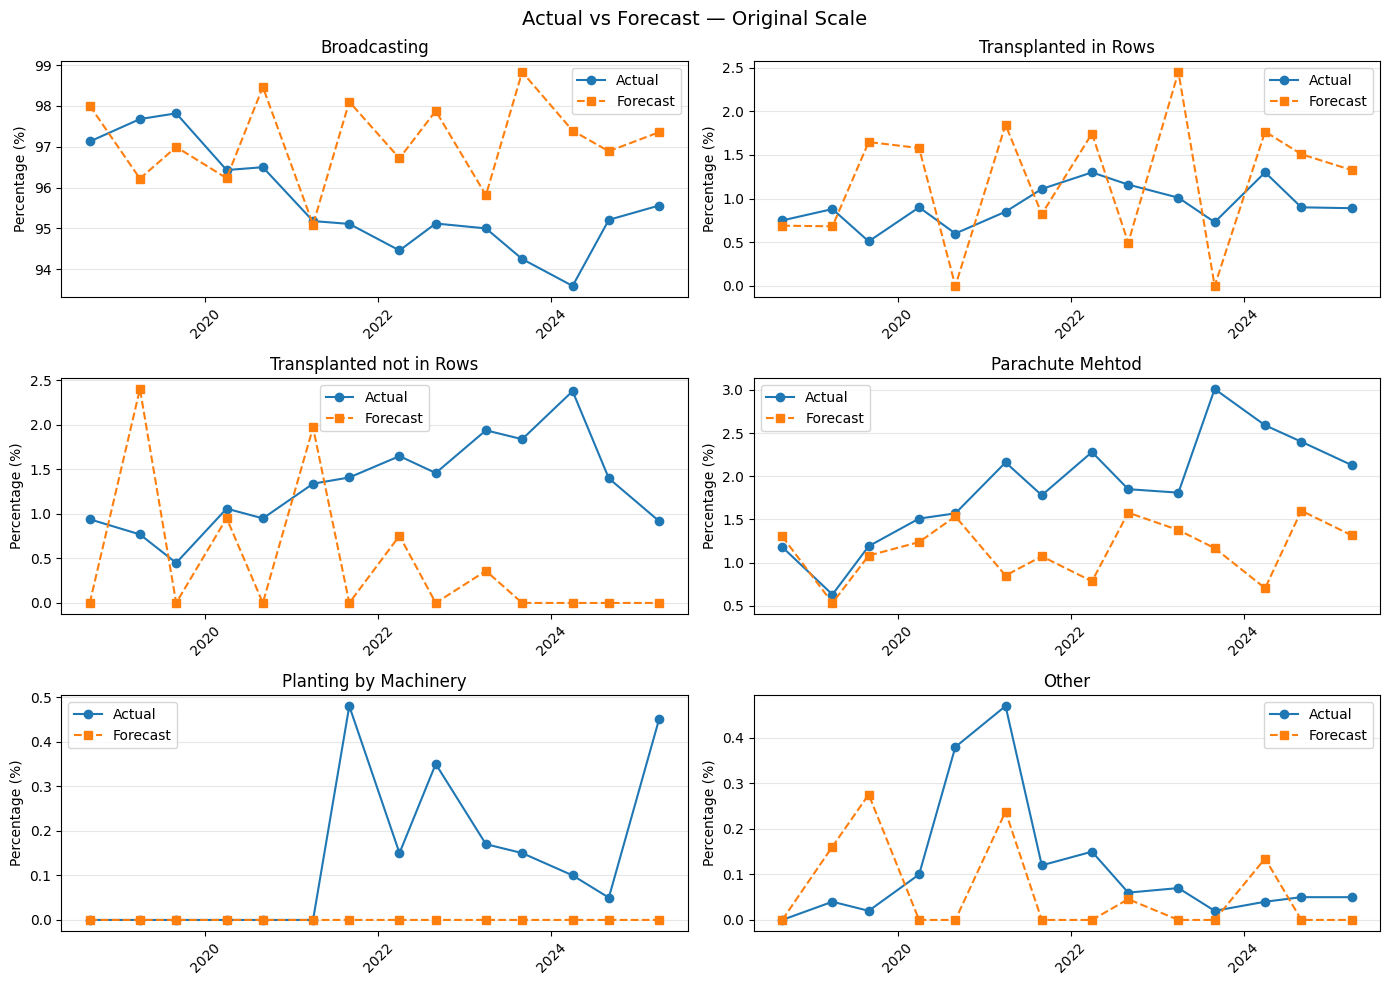

In [16]:
title_map = {
    'Broadcasting': "Broadcasting",
    'Transplant_Rows': "Transplanted in Rows",
    'Transplant_NotRows': "Transplanted not in Rows",
    'Parachute': "Parachute Mehtod",
    'Machine' : "Planting by Machinery" ,
    'Other(sowing)' : "Other"
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, column in enumerate(actual_original.columns):

    axes[i].plot(actual_original.index,
                 actual_original[column],
                 marker='o',
                 label='Actual')

    axes[i].plot(forecast_restored.index,
                 forecast_restored[column],
                 marker='s',
                 linestyle='--',
                 label='Forecast')

    axes[i].set_title(
        title_map.get(column, column),
        fontsize=12
    )

    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle("Actual vs Forecast — Original Scale", fontsize=14)
plt.tight_layout()
plt.show()


2. GRANGER CAUSALITY ANALYSIS
Using lag = 6 (same as VAR model)

Transplant_Rows      → Broadcasting         | F=2.3308  p=0.0550  *
Transplant_NotRows   → Broadcasting         | F=2.0746  p=0.0832  *
Parachute            → Broadcasting         | F=0.1776  p=0.9811  ns
Machine              → Broadcasting         | F=0.6882  p=0.6605  ns
Other(sowing)        → Broadcasting         | F=0.7860  p=0.5871  ns
Broadcasting         → Transplant_Rows      | F=2.8859  p=0.0226  **
Transplant_NotRows   → Transplant_Rows      | F=3.2685  p=0.0124  **
Parachute            → Transplant_Rows      | F=1.3436  p=0.2662  ns
Machine              → Transplant_Rows      | F=0.5616  p=0.7575  ns
Other(sowing)        → Transplant_Rows      | F=1.0043  p=0.4391  ns
Broadcasting         → Transplant_NotRows   | F=1.5766  p=0.1850  ns
Transplant_Rows      → Transplant_NotRows   | F=1.9965  p=0.0944  *
Parachute            → Transplant_NotRows   | F=0.2699  p=0.9471  ns
Machine              → Transplant_NotRow

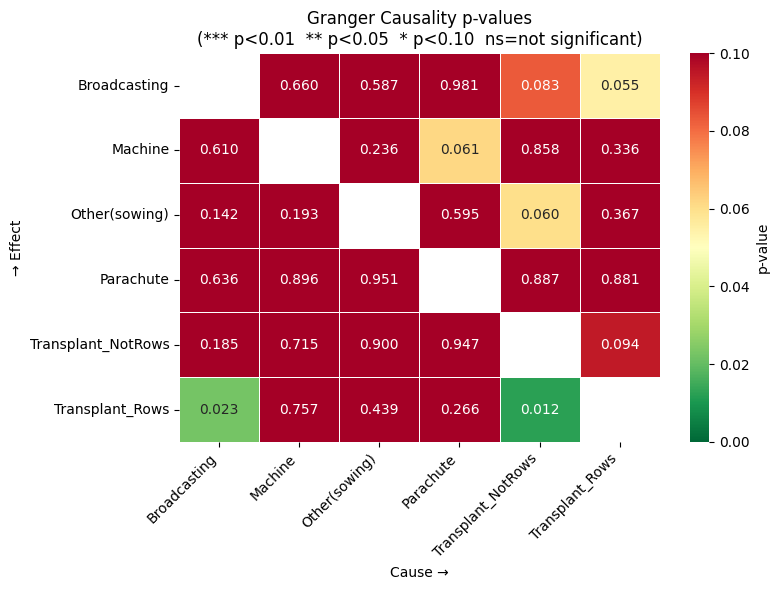

In [17]:
# =========================================================
# 2. GRANGER CAUSALITY — FULL MATRIX
# =========================================================
print("\n" + "="*60)
print("2. GRANGER CAUSALITY ANALYSIS")
print("="*60)
print(f"Using lag = {selected_lag} (same as VAR model)\n")

columns      = train_jittered.columns.tolist()
gc_results   = []

for caused in columns:
    for cause in columns:
        if cause == caused:
            continue
        try:
            test_data = train_jittered[[caused, cause]]
            gc_test   = grangercausalitytests(
                test_data,
                maxlag=selected_lag,
                verbose=False
            )
            p_value = gc_test[selected_lag][0]['ssr_ftest'][1]
            f_stat  = gc_test[selected_lag][0]['ssr_ftest'][0]

            if p_value <= 0.01:
                sig = "***"
            elif p_value <= 0.05:
                sig = "**"
            elif p_value <= 0.10:
                sig = "*"
            else:
                sig = "ns"

            gc_results.append({
                'Cause':        cause,
                'Effect':       caused,
                'F-statistic':  round(f_stat, 4),
                'p-value':      round(p_value, 4),
                'Significance': sig
            })

            print(f"{cause:20s} → {caused:20s} | "
                  f"F={f_stat:.4f}  p={p_value:.4f}  {sig}")

        except Exception as e:
            print(f"  Skipped {cause} → {caused} : {e}")

gc_df = pd.DataFrame(gc_results)

print("\nGranger Causality Summary:")
print(gc_df.to_string(index=False))

# --- Heatmap ---
pivot_p = gc_df.pivot(index='Effect', columns='Cause', values='p-value')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_p,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=0.10,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'p-value'}
)
ax.set_title(
    "Granger Causality p-values\n"
    "(*** p<0.01  ** p<0.05  * p<0.10  ns=not significant)",
    fontsize=12
)
ax.set_xlabel("Cause →")
ax.set_ylabel("→ Effect")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


3. IMPULSE RESPONSE FUNCTIONS (IRF)
IRF plot: shows how a shock in one variable
affects all other variables over time.



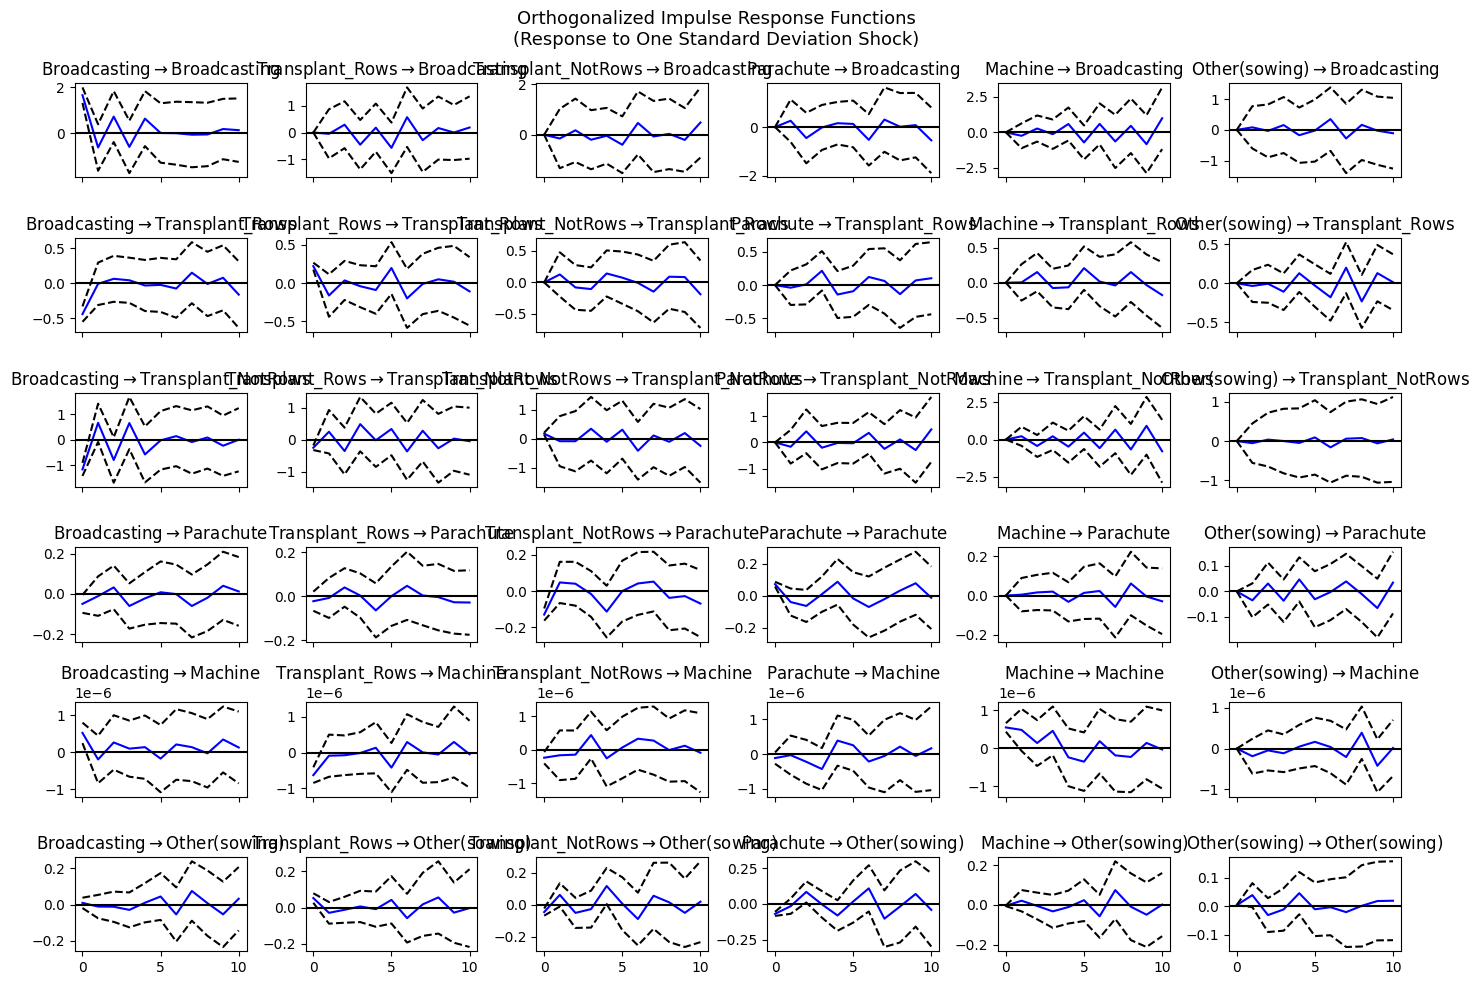

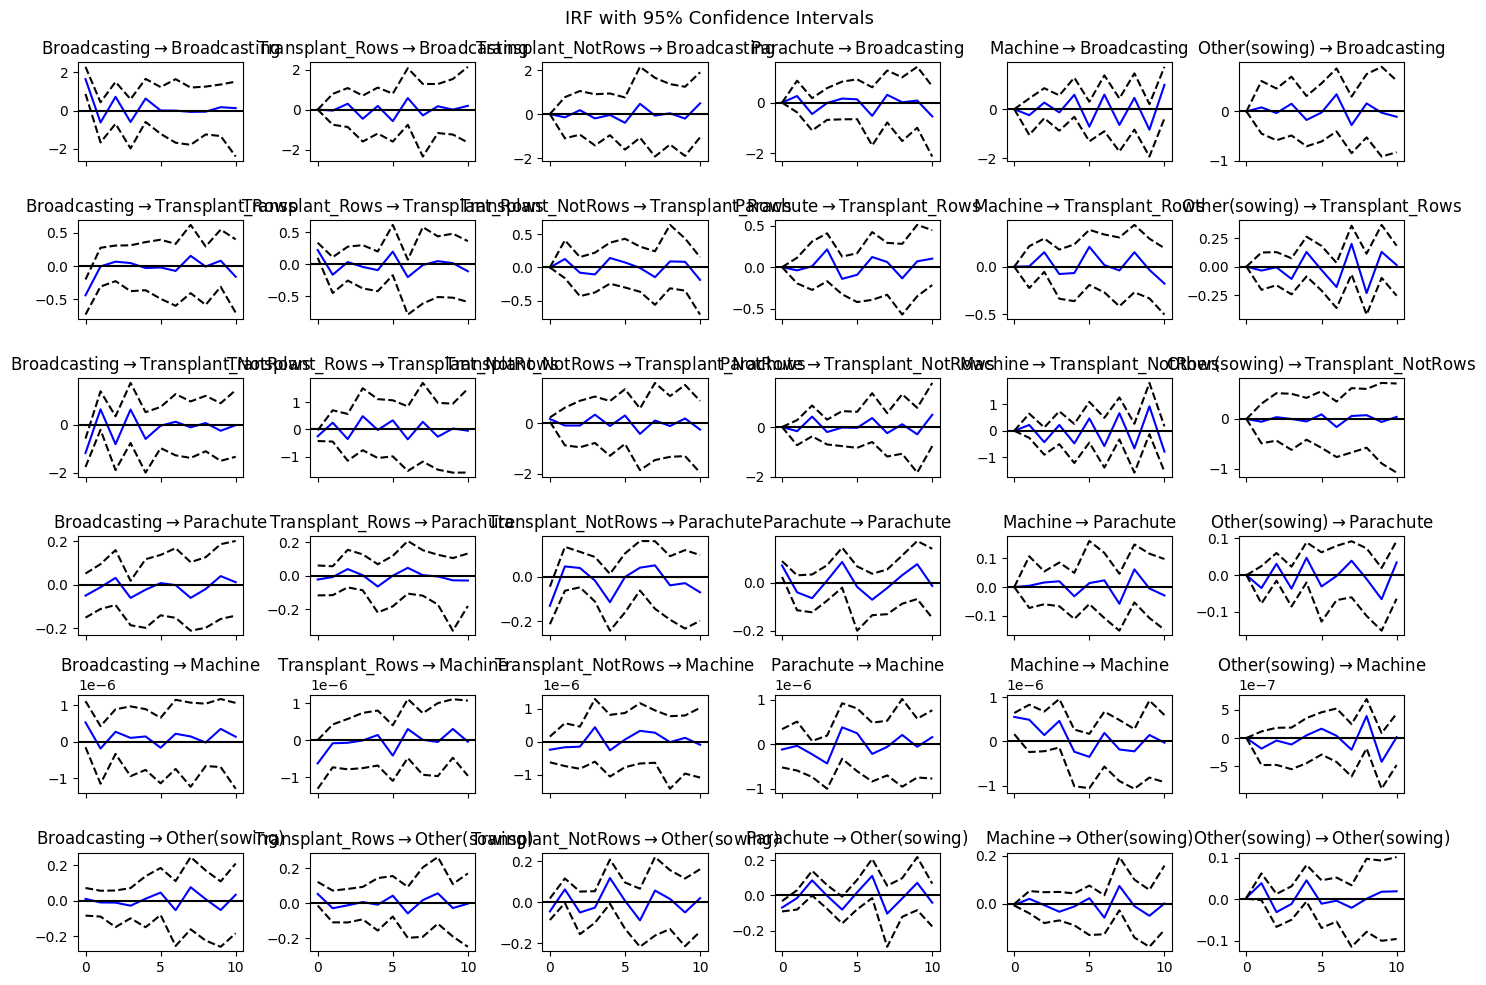

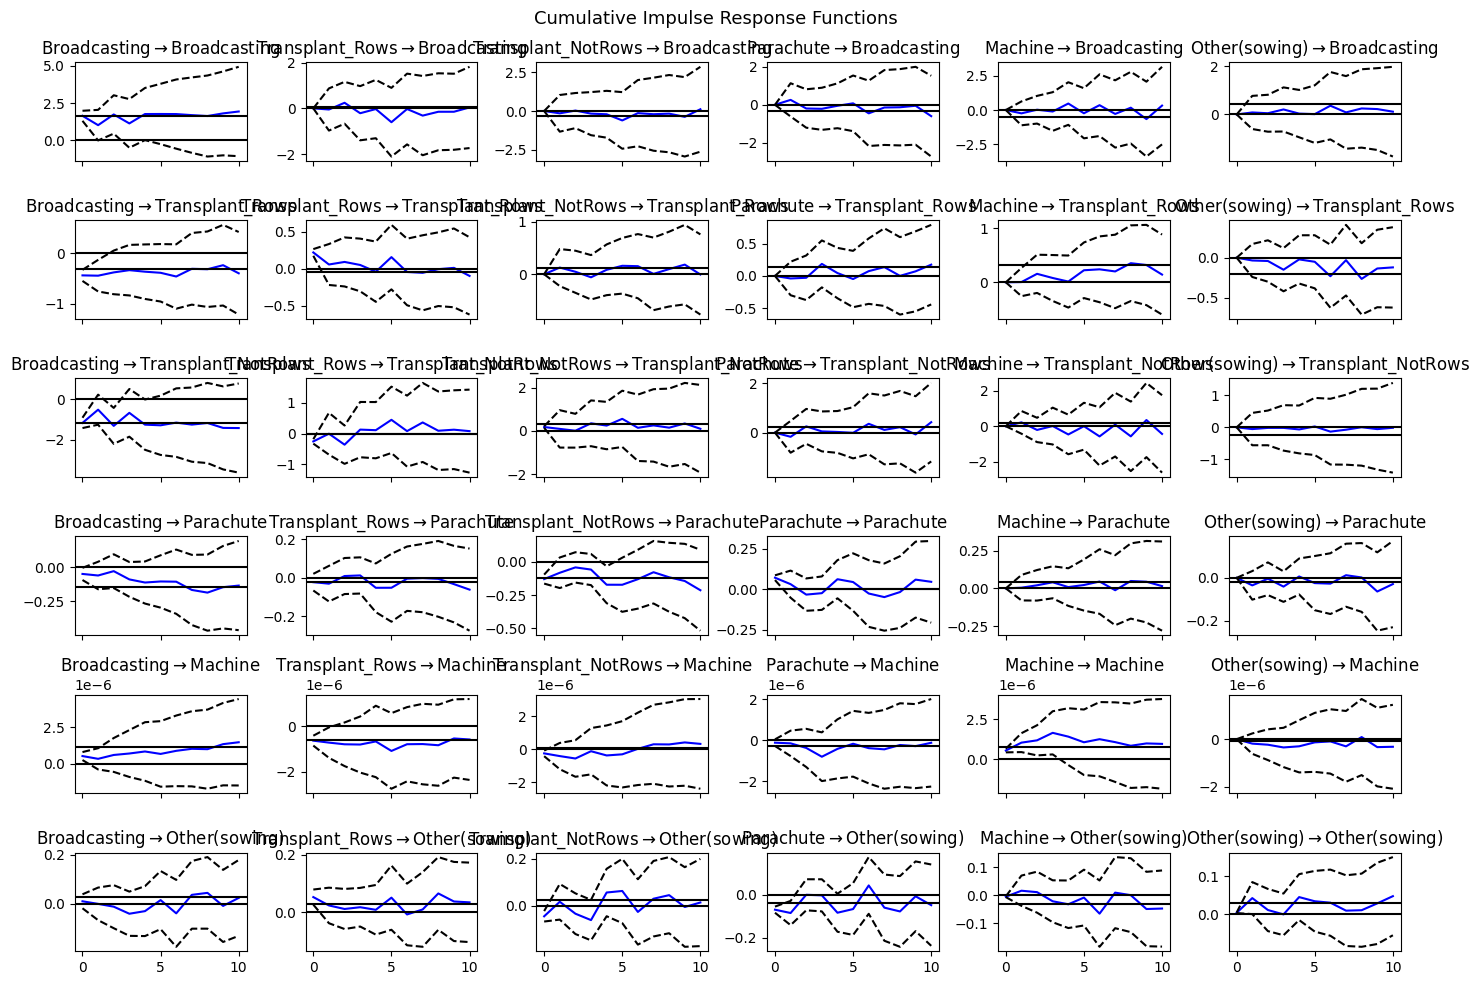

In [18]:

# =========================================================
# 3. IMPULSE RESPONSE FUNCTIONS (IRF)
# =========================================================
print("\n" + "="*60)
print("3. IMPULSE RESPONSE FUNCTIONS (IRF)")
print("="*60)

irf_periods = 10

irf = var_result.irf(periods=irf_periods)

print("IRF plot: shows how a shock in one variable")
print("affects all other variables over time.\n")

# Plot IRF
irf.plot(
    orth=True,
    figsize=(14, 10)
)
plt.suptitle(
    "Orthogonalized Impulse Response Functions\n"
    "(Response to One Standard Deviation Shock)",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Plot IRF with confidence intervals
irf.plot(
    orth=True,
    stderr_type='mc',
    repl=100,
    figsize=(14, 10)
)
plt.suptitle(
    "IRF with 95% Confidence Intervals",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Cumulative IRF
irf.plot_cum_effects(
    orth=True,
    figsize=(14, 10)
)
plt.suptitle(
    "Cumulative Impulse Response Functions",
    fontsize=13
)
plt.tight_layout()
plt.show()


4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
FEVD: shows what % of each variable's forecast
error variance is explained by each variable.

FEVD Shape: (6, 10, 6)

--------------------------------------------------
FEVD for Broadcasting
--------------------------------------------------
        Broadcasting  Transplant_Rows  Transplant_NotRows  Parachute  Machine  Other(sowing)
Period                                                                                      
1             100.00             0.00                0.00       0.00     0.00           0.00
2              95.16             0.07                0.67       2.05     1.84           0.21
3              86.80             2.12                1.28       6.47     3.15           0.19
4              82.57             6.16                1.91       5.60     3.08           0.67
5              77.46             5.85                1.66       5.23     8.70           1.10
6              65.68             9.92                3.76 

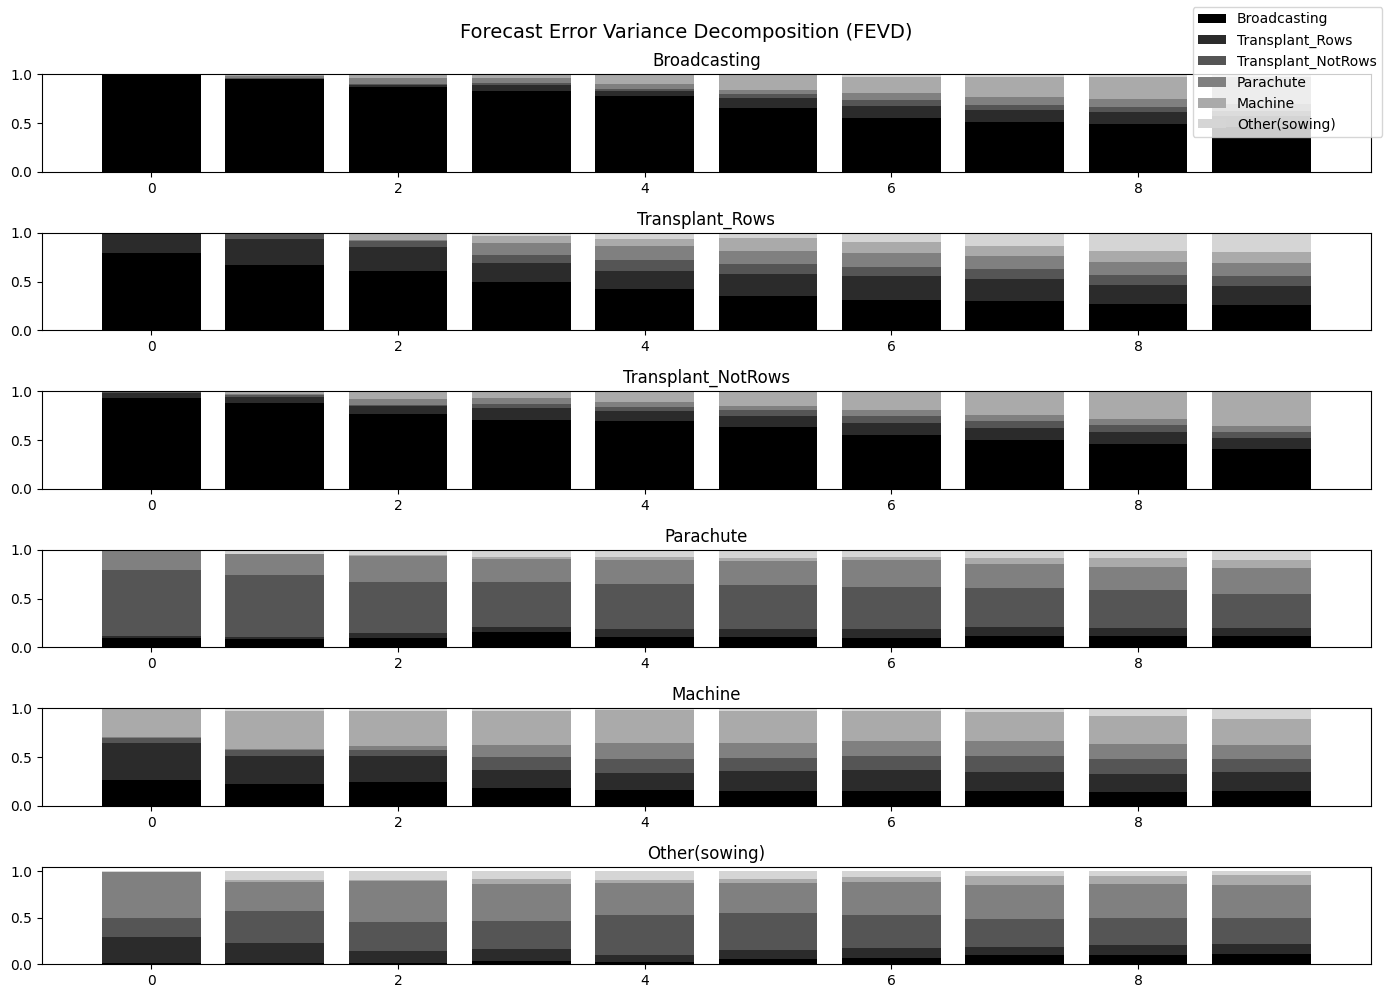

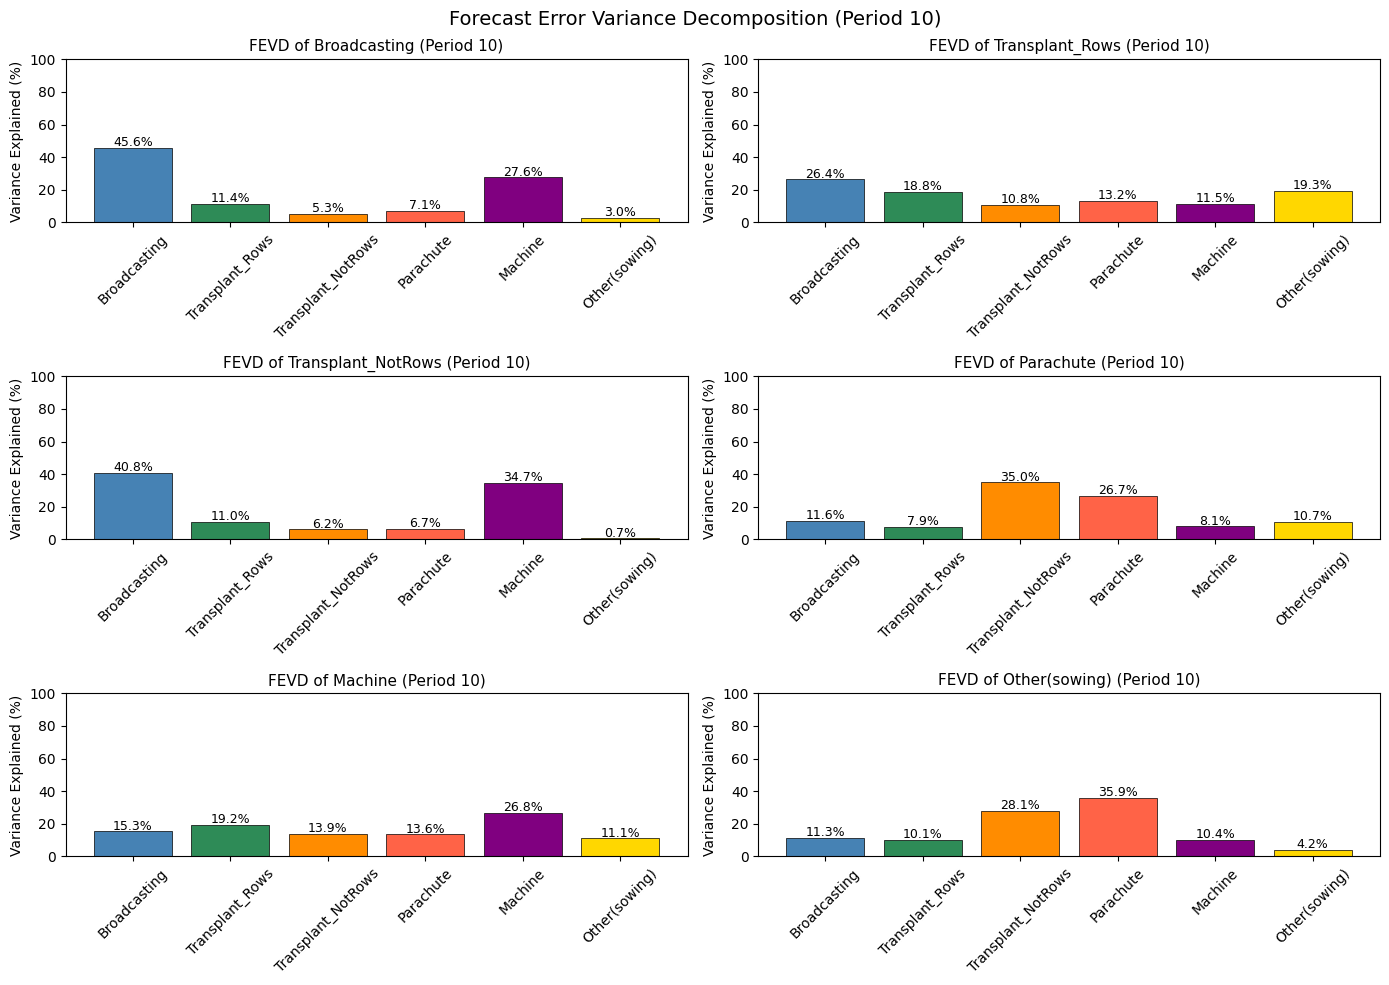

In [19]:
# =========================================================
# 4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
# =========================================================

print("\n" + "="*60)
print("4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)")
print("="*60)

fevd_periods = 10

# Compute FEVD
fevd = var_result.fevd(fevd_periods)

print("FEVD: shows what % of each variable's forecast")
print("error variance is explained by each variable.\n")

# Extract FEVD array
fevd_results = fevd.decomp

print("FEVD Shape:", fevd_results.shape)

# =========================================================
# FEVD TABLES
# =========================================================

for i, col in enumerate(df.columns):

    print(f"\n{'-'*50}")
    print(f"FEVD for {col}")
    print(f"{'-'*50}")

    fevd_df = pd.DataFrame(
        fevd_results[i, :, :],   # Variable i, all periods, all contributors
        columns=df.columns
    )

    fevd_df.index = np.arange(1, len(fevd_df) + 1)
    fevd_df.index.name = "Period"

    print((fevd_df * 100).round(2).to_string())

# =========================================================
# BUILT-IN FEVD PLOT
# =========================================================

fevd.plot(figsize=(14, 10))
plt.suptitle(
    "Forecast Error Variance Decomposition (FEVD)",
    fontsize=14
)
plt.tight_layout()
plt.show()

# =========================================================
# CUSTOM FEVD BAR CHART AT FINAL PERIOD
# =========================================================

n_vars = len(df.columns)

fig, axes = plt.subplots(
    nrows=int(np.ceil(n_vars / 2)),
    ncols=2,
    figsize=(14, 10)
)

axes = np.array(axes).flatten()

colors_fevd = [
    'steelblue',
    'seagreen',
    'darkorange',
    'tomato',
    'purple',
    'gold'
]

# Use last available FEVD period
period_to_plot = min(fevd_periods, fevd_results.shape[1])

for i, col in enumerate(df.columns):

    # FEVD values at selected period
    fevd_at_period = fevd_results[i, period_to_plot - 1, :] * 100

    axes[i].bar(
        df.columns,
        fevd_at_period,
        color=colors_fevd[:n_vars],
        edgecolor='black',
        linewidth=0.5
    )

    axes[i].set_title(
        f"FEVD of {col} (Period {period_to_plot})",
        fontsize=11
    )

    axes[i].set_ylabel("Variance Explained (%)")
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=45)

    for j, val in enumerate(fevd_at_period):
        axes[i].text(
            j,
            val + 1,
            f"{val:.1f}%",
            ha='center',
            fontsize=9
        )

# Remove unused subplots
for k in range(n_vars, len(axes)):
    fig.delaxes(axes[k])

plt.suptitle(
    f"Forecast Error Variance Decomposition (Period {period_to_plot})",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:

# # =========================================================
# # SAVE ALL RESULTS
# # =========================================================
# forecast_restored.to_excel("VAR_Forecasts.xlsx")

# with pd.ExcelWriter("VAR_Full_Analysis.xlsx") as writer:
#     evaluation_df.to_excel(writer, sheet_name='Accuracy',          index=False)
#     gc_df.to_excel(        writer, sheet_name='Granger_Causality', index=False)

#     for i, col in enumerate(df.columns):
#         fevd_df = pd.DataFrame(
#             fevd_results[:, i, :],
#             columns=df.columns
#         )
#         fevd_df.index = fevd_df.index + 1
#         fevd_df.index.name = 'Period'
#         fevd_df.to_excel(writer, sheet_name=f'FEVD_{col[:10]}')

# print("\nAll results saved to VAR_Full_Analysis.xlsx")
# print("Forecasts saved to VAR_Forecasts.xlsx")
# print("\nDone.")